# Stage 07: Outliers and Risk Assumptions

Stage 07. **I based it on the lecture notebook.**

In [1]:
# Install missing packages (uncomment and run to install).
# !pip install pandas matplotlib python-dotenv scikit-learn

In [2]:
from pathlib import Path

# Project root.
ROOT = Path.cwd()
if not (ROOT/".env.example").exists() and (ROOT.parent/".env.example").exists():
    ROOT = ROOT.parent

CHECKS = [
    ("src/outliers.py", "NEEDED", "IQR, Z-score, and winsorize helpers"),
    ("data/raw/prismatic_evoluations_prices.csv", "NEEDED", "Prismatic Evolutions prices"),
]

print(f"Looking in: {ROOT}\n")
missing = 0
for rel, kind, note in CHECKS:
    here = (ROOT/rel).exists()
    if not here and kind == "NEEDED":
        missing += 1
    print(f"  [{'OK ' if here else 'MISS'}]  {kind:<8}  {rel:<34}  {note}")

if missing:
    raise FileNotFoundError(f"{missing} needed file(s) missing under {ROOT}")
print("\nAll needed files present.")

Looking in: /Users/ghostof0days/projects/bootcamp/project

  [OK ]  NEEDED    src/outliers.py                     IQR, Z-score, and winsorize helpers
  [OK ]  NEEDED    data/raw/prismatic_evoluations_prices.csv  Prismatic Evolutions prices

All needed files present.


In [3]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Import helpers from src/.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import get_key
from src.outliers import detect_outliers_iqr, detect_outliers_zscore, winsorize_series

# Load `.env`.
load_dotenv(ROOT/".env")

# folders from .env.
RAW = ROOT/(get_key("DATA_DIR_RAW", "data/raw") or "data/raw")
PROC = ROOT/(get_key("DATA_DIR_PROCESSED", "data/processed") or "data/processed")
PROC.mkdir(parents=True, exist_ok=True)
print("RAW:", RAW.resolve())
print("PROC:", PROC.resolve())

RAW: /Users/ghostof0days/projects/bootcamp/project/data/raw
PROC: /Users/ghostof0days/projects/bootcamp/project/data/processed


## Load raw prices

In [4]:
# load the raw csv.
card_prices = pd.read_csv(RAW/"prismatic_evoluations_prices.csv", parse_dates=["date"])
print("Original shape:", card_prices.shape)
print("Original NA count:\n", card_prices.isna().sum())
card_prices.head()

Original shape: (61279, 4)
Original NA count:
 card_name       0
rarity          0
market_price    0
date            0
dtype: int64


,card_name,rarity,market_price,date
0,Amarys - 132/131 | Holofoil,Ultra Rare,4.09,2025-01-17
1,Applin (Master Ball Pattern) | Holofoil,Common,9.99,2025-01-17
2,Applin (Poke Ball Pattern) | Holofoil,Common,3.58,2025-01-17
3,Archaludon (Master Ball Pattern) | Holofoil,Rare,20.00,2025-01-17
4,Area Zero Underdepths (Poke Ball Pattern) | Ho...,Uncommon,4.44,2025-01-17


## Detect outliers and create flags

In [5]:
# drop non-positive prices.
positive = card_prices[card_prices["market_price"] > 0].copy()

# flag outliers on market_price. k=0.5 because 1.5 still flags about 0.13 here.
target_column = "market_price"
positive["outlier_iqr"] = detect_outliers_iqr(positive[target_column], k=0.5)
positive["outlier_zscore"] = detect_outliers_zscore(positive[target_column], threshold=3.0)
# mean of a boolean mask is the outlier fraction.
iqr_outlier_fraction = positive["outlier_iqr"].mean()
zscore_outlier_fraction = positive["outlier_zscore"].mean()
# unique flagged cards.
iqr_outliers = positive.loc[positive["outlier_iqr"], ["card_name", "rarity", target_column]].drop_duplicates()
print("IQR outlier fraction:", iqr_outlier_fraction)
print("Z-score outlier fraction:", zscore_outlier_fraction)
print(iqr_outliers)

IQR outlier fraction: 0.18942867866642732
Z-score outlier fraction: 0.012402291160103787
                                              card_name  \
11                     Bloodmoon Ursaluna ex | Holofoil   
21     Cornerstone Mask Ogerpon ex - 160/131 | Holofoil   
24                    Dragapult ex - 165/131 | Holofoil   
37                        Eevee ex - 167/131 | Holofoil   
49                              Gholdengo ex | Holofoil   
...                                                 ...   
61247                   Pikachu ex - 179/131 | Holofoil   
61263                   Sylveon ex - 156/131 | Holofoil   
61269          Umbreon (Master Ball Pattern) | Holofoil   
61272                   Umbreon ex - 161/131 | Holofoil   
61275                  Vaporeon ex - 149/131 | Holofoil   

                          rarity  market_price  
11     Special Illustration Rare         99.99  
21     Special Illustration Rare         98.00  
24     Special Illustration Rare         89.14  
37    

## Figures

Saved: /Users/ghostof0days/projects/bootcamp/project/data/processed/price_boxplot.png


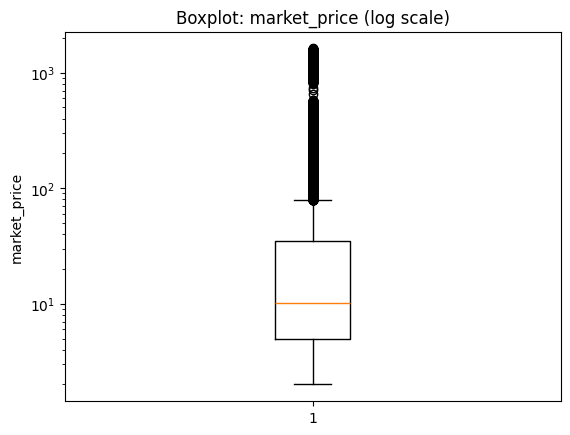

Saved: /Users/ghostof0days/projects/bootcamp/project/data/processed/price_histogram.png


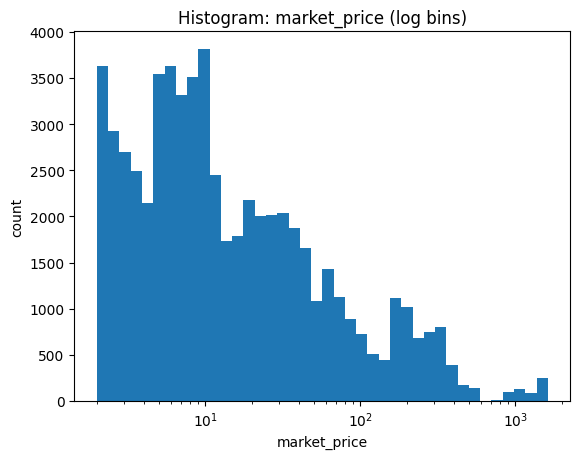

In [6]:
# boxplot and histogram of market_price. log scale so SIRs do not squash the bulk.
boxplot_path = PROC/"price_boxplot.png"
plt.figure()
plt.boxplot(positive[target_column])
plt.yscale("log")
plt.title(f"Boxplot: {target_column} (log scale)")
plt.ylabel(target_column)
plt.savefig(boxplot_path, bbox_inches="tight")
print("Saved:", boxplot_path)
plt.show()

# log-spaced bins. linear bins dump most rows into the first bar after xscale log.
histogram_path = PROC/"price_histogram.png"
price_min = positive[target_column].min()
price_max = positive[target_column].max()
price_bins = np.logspace(np.log10(price_min), np.log10(price_max), 41)
plt.figure()
plt.hist(positive[target_column], bins=price_bins)
plt.xscale("log")
plt.title(f"Histogram: {target_column} (log bins)")
plt.xlabel(target_column)
plt.ylabel("count")
plt.savefig(histogram_path, bbox_inches="tight")
print("Saved:", histogram_path)
plt.show()

## Sensitivity analysis

In [7]:
# ~ flips the iqr mask so I keep non-outlier rows.
summary_all = positive[target_column].describe()[["mean", "50%", "std"]].rename({"50%": "median"})
summary_outliers_dropped = positive.loc[~positive["outlier_iqr"], target_column].describe()[["mean", "50%", "std"]].rename({"50%": "median"})
# clip tails at 5% and 95%.
winsorized = winsorize_series(positive[target_column])
summary_winsorized = winsorized.describe()[["mean", "50%", "std"]].rename({"50%": "median"})
comparison = pd.concat({"all": summary_all, "outliers_dropped": summary_outliers_dropped, "winsorized": summary_winsorized}, axis=1)
print("Summary statistics:")
comparison

Summary statistics:


,all,outliers_dropped,winsorized
mean,51.546560,12.326210,38.058473
median,10.100000,7.830000,10.100000
std,141.875164,11.375027,62.820303


In [8]:
# map rarity text to a number.
rarity_rank = {
    "Code Card": 0,
    "Sealed": 0,
    "Common": 1,
    "Uncommon": 2,
    "Rare": 3,
    "Double Rare": 4,
    "Ultra Rare": 5,
    "ACE SPEC Rare": 6,
    "Special Illustration Rare": 7,
    "Hyper Rare": 8,
}
positive["rarity_rank"] = positive["rarity"].map(rarity_rank)
# same regression on all rows, dropped outliers, and winsorized y.
print("Regressing", target_column, "on rarity_rank")

rows_without_outliers = ~positive["outlier_iqr"]
features_all = positive[["rarity_rank"]].to_numpy()
response_all = positive[target_column].to_numpy()
features_outliers_dropped = positive.loc[rows_without_outliers, ["rarity_rank"]].to_numpy()
response_outliers_dropped = positive.loc[rows_without_outliers, target_column].to_numpy()
features_winsorized = positive[["rarity_rank"]].to_numpy()
response_winsorized = winsorized.to_numpy()

model_all = LinearRegression().fit(features_all, response_all)
model_outliers_dropped = LinearRegression().fit(features_outliers_dropped, response_outliers_dropped)
model_winsorized = LinearRegression().fit(features_winsorized, response_winsorized)

results = pd.DataFrame({
    "slope": [model_all.coef_[0], model_outliers_dropped.coef_[0], model_winsorized.coef_[0]],
    "intercept": [model_all.intercept_, model_outliers_dropped.intercept_, model_winsorized.intercept_],
    "r2": [
        model_all.score(features_all, response_all),
        model_outliers_dropped.score(features_outliers_dropped, response_outliers_dropped),
        model_winsorized.score(features_winsorized, response_winsorized),
    ],
    "mae": [
        mean_absolute_error(response_all, model_all.predict(features_all)),
        mean_absolute_error(response_outliers_dropped, model_outliers_dropped.predict(features_outliers_dropped)),
        mean_absolute_error(response_winsorized, model_winsorized.predict(features_winsorized)),
    ],
}, index=["all", "outliers_dropped", "winsorized"])
print("Regression comparison:")
results

Regressing market_price on rarity_rank
Regression comparison:


,slope,intercept,r2,mae
all,20.048281,-28.524533,0.123788,55.902220
outliers_dropped,2.732391,3.090561,0.305700,6.955241
winsorized,13.544966,-16.038942,0.288200,34.435001


Saved: /Users/ghostof0days/projects/bootcamp/project/data/processed/regression_fits.png


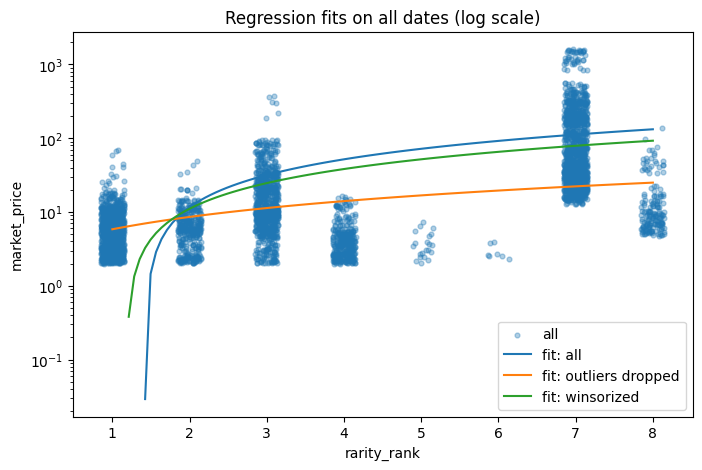

Saved: /Users/ghostof0days/projects/bootcamp/project/data/processed/treatment_boxplots.png


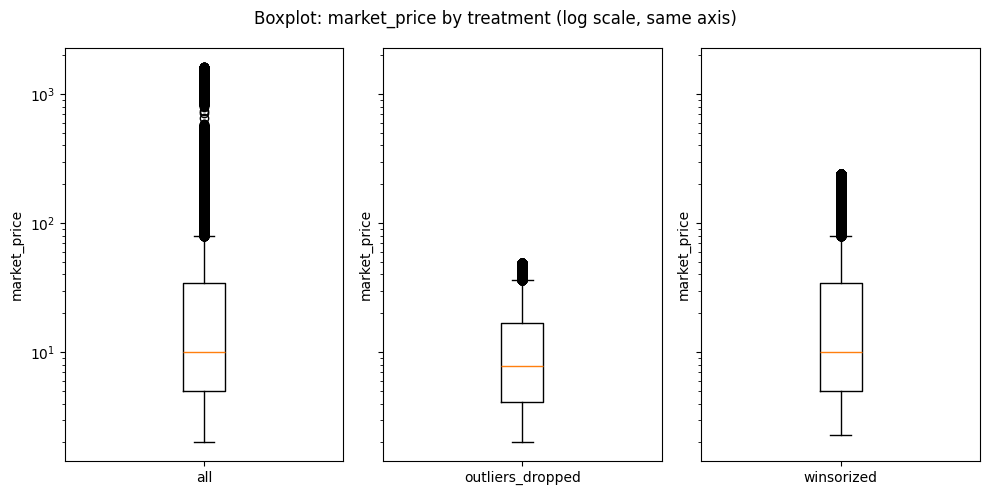

In [9]:
# scatter of a date sample plus the three fit lines. same rows the models were fit on. log y so SIRs do not squash the bulk. a little spread so same-rank points do not pile up.
rng = np.random.default_rng(0)
plot_sample = positive.sample(n=min(4000, len(positive)), random_state=0)
rarity_rank_for_plot = plot_sample["rarity_rank"] + rng.uniform(-0.15, 0.15, size=len(plot_sample))
regression_fits_path = PROC/"regression_fits.png"
plt.figure(figsize=(8, 5))
plt.scatter(rarity_rank_for_plot, plot_sample[target_column], label="all", alpha=0.35, s=12)
x_line = np.linspace(positive["rarity_rank"].min(), positive["rarity_rank"].max(), 100)

def positive_fit_line(slope, intercept, x_values):
    # linear dollar fit. skip where predicted price is not positive so log y can draw it.
    predicted = slope * x_values + intercept
    keep = predicted > 0
    return x_values[keep], predicted[keep]

x_all, y_all = positive_fit_line(model_all.coef_[0], model_all.intercept_, x_line)
x_dropped, y_dropped = positive_fit_line(model_outliers_dropped.coef_[0], model_outliers_dropped.intercept_, x_line)
x_winsorized, y_winsorized = positive_fit_line(model_winsorized.coef_[0], model_winsorized.intercept_, x_line)
plt.plot(x_all, y_all, label="fit: all")
plt.plot(x_dropped, y_dropped, label="fit: outliers dropped")
plt.plot(x_winsorized, y_winsorized, label="fit: winsorized")
plt.yscale("log")
plt.legend()
plt.title("Regression fits on all dates (log scale)")
plt.xlabel("rarity_rank")
plt.ylabel(target_column)
plt.savefig(regression_fits_path, bbox_inches="tight")
print("Saved:", regression_fits_path)
plt.show()

# same log axis so dropped and winsorized tails are shorter, not just rescaled.
treatment_boxplots_path = PROC/"treatment_boxplots.png"
fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharey=True)
treatment_series = [
    positive[target_column],
    positive.loc[rows_without_outliers, target_column],
    winsorized,
]
treatment_labels = ["all", "outliers_dropped", "winsorized"]
for axis, series, label in zip(axes, treatment_series, treatment_labels):
    axis.boxplot(series, tick_labels=[label])
    axis.set_yscale("log")
    axis.set_ylabel(target_column)
fig.suptitle(f"Boxplot: {target_column} by treatment (log scale, same axis)")
fig.tight_layout()
plt.savefig(treatment_boxplots_path, bbox_inches="tight")
print("Saved:", treatment_boxplots_path)
plt.show()

In [10]:
# write the regression table.
sensitivity_path = PROC/"outlier_sensitivity.csv"
results.to_csv(sensitivity_path)
print("Saved sensitivity CSV:", sensitivity_path)

Saved sensitivity CSV: /Users/ghostof0days/projects/bootcamp/project/data/processed/outlier_sensitivity.csv


## Documentation

- I flagged IQR outliers on `market_price` with k=0.5.
- I also flagged Z-score outliers with threshold 3.0.
- I dropped rows with non-positive `market_price` before flagging.
- I winsorized `market_price` at 5% and 95%.
- I compared mean, median, and std for all, filtered, and winsorized.
- I fit a linear regression of `market_price` on rarity rank for those three treatments.
- I saved the regression table to `data/processed/outlier_sensitivity.csv`.
- I put the helpers in `src/outliers.py`.
- I added the README Outliers and Risk Assumptions section in `project/README.md`.

Assumptions and risks:
- When I used IQR with k=0.5,I assumed quartiles could capture the majority of card prices.
- When I used Z-score with ddof=0, I assumed a roughly normal sample.
- When I winsorized at 5%/95%, I assumed the tails are noisy.
- If those expensive SIRs are the cards my screener should rank, then dropping them would hide the signal.

## Reflection

I chose IQR with k=0.5 because Prismatic prices are right-skewed. This is because commons sit near the $2 floor and SIRs are far above the median price. I don't assume normality because mean and standard deviation get pulled up by the high-end cards, so the quartiles better represent the bulk. The k=1.5 from lecture flagged about 0.13 since Q3 is already about $35 and the IQR cutoff sits below Umbreon. I computed Z-score at 3.0, so I could see whether the same cards were flagged. For Z-score, I used population standard deviation because of labeling this sample instead of estimating a population parameter. I also ran winsorize at 5%/95% to keep every row but make a cap for the tails.

My decisions assume the expensive SIRs are mostly unusual relative to a typical card. This is risky because Umbreon ex is an actual card instead of data that can be discarded. The data I used also has no missing values after I dropped non-positive prices, so dealing with NA didn't change anything. I made NA flags as False and rejected empty series and non-positive k or threshold to stop bad inputs.

Dropping the IQR outliers reduced the mean and standard deviation of `market_price` a lot since SIRs were a large part of both. Median changed less as I expected. I also ran the regression of `market_price` on rarity_rank for all three versions. When I left the SIRs in, slope and MAE got moved a lot by those high prices. Without these datapoints in, the slope is flatter. Winsorize was between the two. I also looked at R^2 since dropping points can make the R^2 go up even when I threw away real cards.

If those SIRs were actually the cards my screener should rank, then me dropping them would make the market look less spread than it actually is. If I picked k to be too small, I would end up flagging ordinary cards. If I just used Z-score on the sample, the SIRs would increase standatrd deviation a lot and I might miss them.